In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)



In [2]:
# 1. Carga y Preparación del Dataset Transversal
df = pd.read_csv('oasis_cross-sectional.csv')

# Selección de atributos predictores
features = ['Sex', 'Age', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = df[features].copy()
X['Sex'] = X['Sex'].map({'M': 0, 'F': 1})

# --- LINEAMIENTO: Binarización de CDR (2 Clases) ---
# 0 = "non demented" (CDR 0), 1 = "demented" (CDR >= 0.5)
y = df['CDR'].apply(lambda x: 1 if x >= 0.5 else 0)

# 2. Tratamiento de Datos Faltantes (SES y Educ)
imputer = SimpleImputer(strategy='median')
X_prep = imputer.fit_transform(X)



/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['Sex']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Ejecutando 10 iteraciones de validación independiente para SVM...


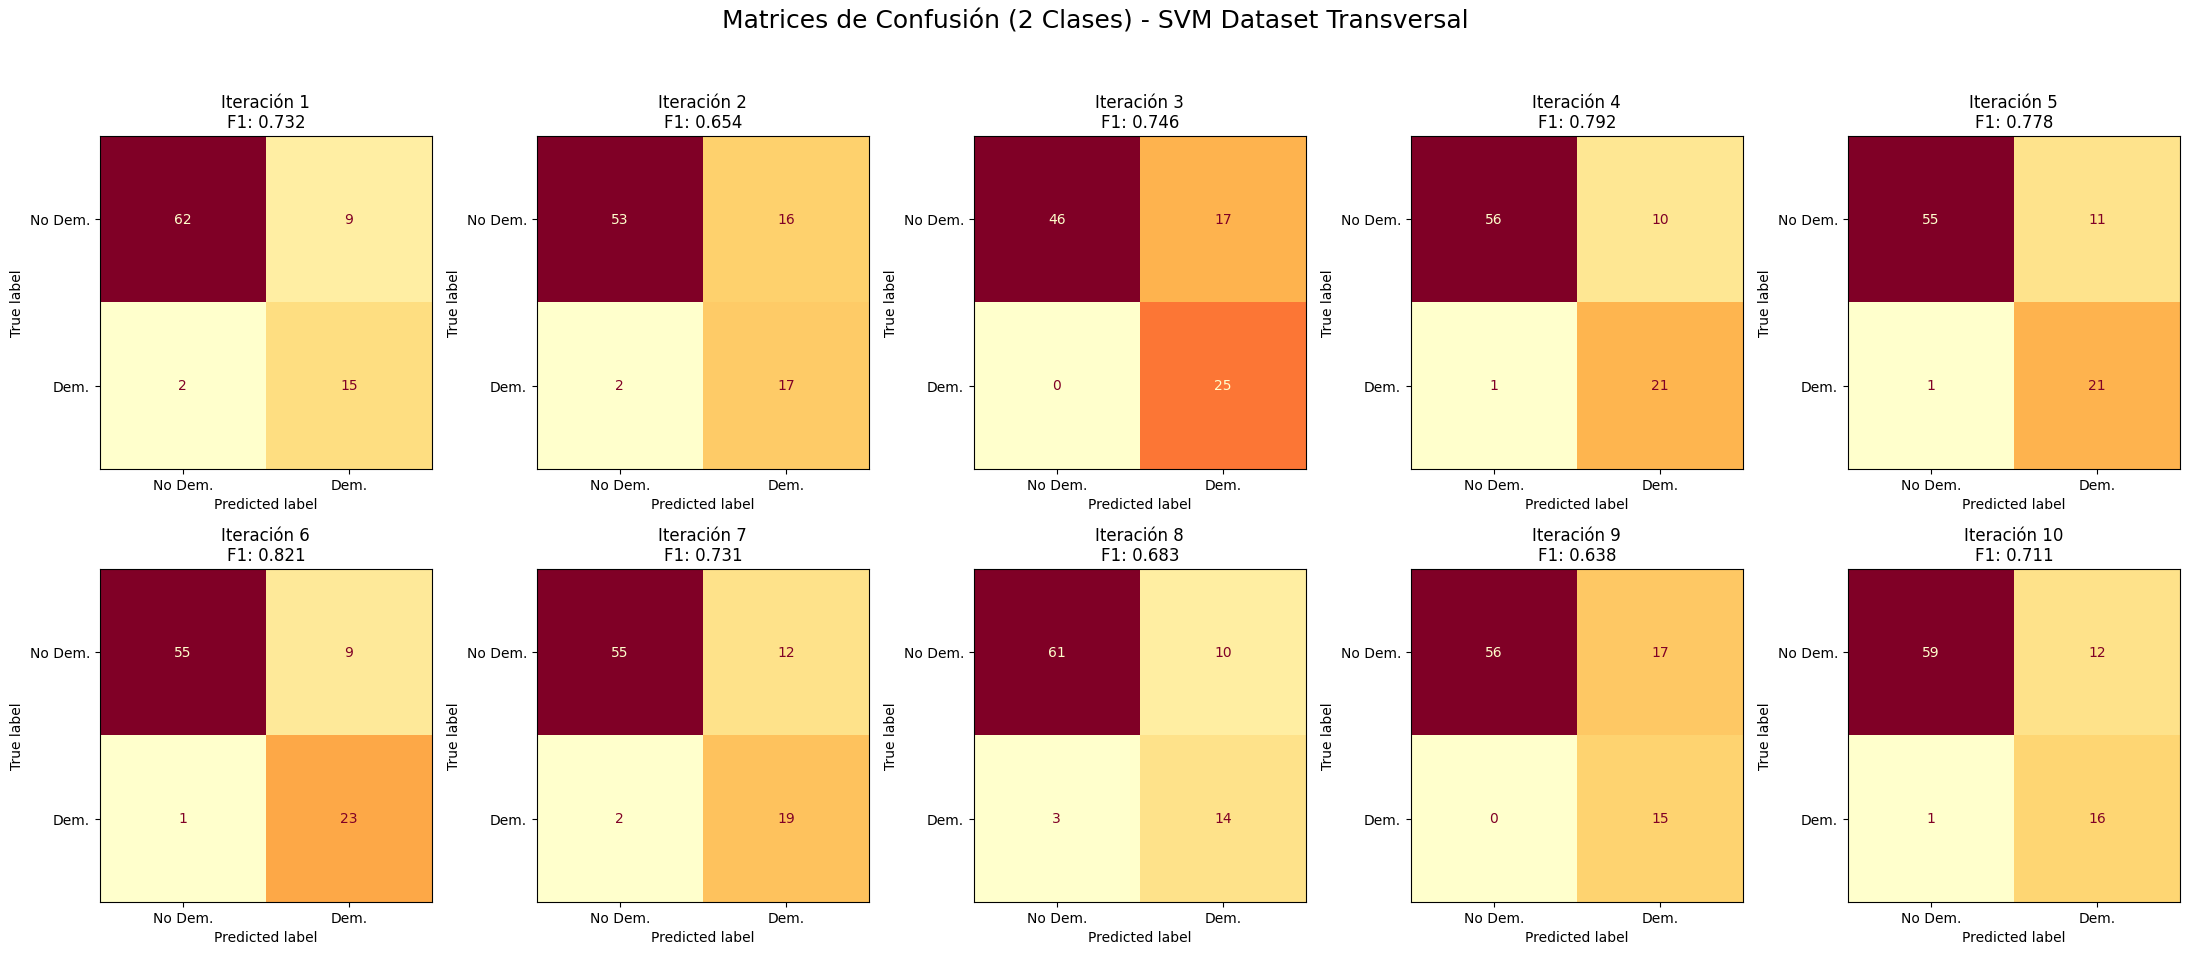


--- DESEMPEÑO FINAL SVM (10 ITERACIONES) ---
Métrica                   | Promedio ± DE            
-------------------------------------------------------
ACC                       | 0.8455 ± 0.0306
PREC                      | 0.6024 ± 0.0704
REC                       | 0.9314 ± 0.0523
F1                        | 0.7287 ± 0.0562
AUC                       | 0.9514 ± 0.0161


In [ ]:
# 3. Diseño Experimental: 10 Validaciones Independientes 80/20
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("Ejecutando 10 iteraciones de validación independiente para SVM...")

for i in range(10):
    # Partición aleatoria única por iteración
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # 4. Escalamiento Z-score: Requisito Crítico para SVM [2]
    # Se ajusta en entrenamiento y se aplica en prueba para evitar filtración
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # 5. Entrenamiento del Modelo SVM
    # kernel='rbf' por defecto (estándar para datos no lineales)
    # class_weight='balanced' para mitigar el desbalance de clases [4]
    svm = SVC(kernel='rbf', C=1.0, probability=True, class_weight='balanced', random_state=42)
    svm.fit(X_train_s, y_train)
    
    # Predicciones
    y_pred = svm.predict(X_test_s)
    y_proba = svm.predict_proba(X_test_s)[:, 1]
    
    # 6. Registro de Métricas [5]
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred))
    results['rec'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['auc'].append(roc_auc_score(y_test, y_proba))
    
    # 7. Matrices de Confusión por iteración [Instrucción de estilo]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Dem.', 'Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Iteración {i+1}\nF1: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión (2 Clases) - SVM Dataset Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 8. Reporte Final de Desempeño (Media ± DE) [6]
print("\n" + "="*55)
print(f"--- DESEMPEÑO FINAL SVM (10 ITERACIONES) ---")
print(f"{'Métrica':<25} | {'Promedio ± DE':<25}")
print("-" * 55)
for m in results:
    print(f"{m.upper():<25} | {np.mean(results[m]):.4f} ± {np.std(results[m]):.4f}")
print("="*55)